In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('RDS_USER')}:{os.getenv('RDS_PASSWORD')}"
    f"@{os.getenv('RDS_HOST')}/{os.getenv('RDS_DATABASE')}"
)

print("✅ Connected to database")

✅ Connected to database


In [2]:
df = pd.read_sql("""
    SELECT 
        order_id,
        customer_id,
        gross_revenue,
        order_purchase_timestamp,
        purchase_month,
        purchase_year,
        delivery_days,
        is_late
    FROM fact_orders
    WHERE gross_revenue IS NOT NULL
    ORDER BY order_purchase_timestamp
""", engine)

print(f"✅ Loaded {len(df):,} orders from database")
df.head()

✅ Loaded 96,478 orders from database


,order_id,customer_id,gross_revenue,order_purchase_timestamp,purchase_month,purchase_year,delivery_days,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,134.97,2016-09-15 12:16:38,9,2016,54.0,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,29.90,2016-10-03 09:44:50,10,2016,23.0,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,21.90,2016-10-03 16:56:50,10,2016,24.0,0
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,36.49,2016-10-03 21:13:36,10,2016,30.0,0
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,119.90,2016-10-03 22:06:03,10,2016,27.0,0


In [3]:
# Split dataset into two equal halves by time
# First half = Control (standard shipping threshold $100)
# Second half = Treatment (reduced shipping threshold $50)

df = df.sort_values('order_purchase_timestamp').reset_index(drop=True)
midpoint = len(df) // 2

df['test_group'] = 'control'
df.loc[midpoint:, 'test_group'] = 'treatment'

control = df[df['test_group'] == 'control']['gross_revenue']
treatment = df[df['test_group'] == 'treatment']['gross_revenue']

print(f"Control group size: {len(control):,}")
print(f"Treatment group size: {len(treatment):,}")
print(f"\nControl mean: ${control.mean():.2f}")
print(f"Treatment mean: ${treatment.mean():.2f}")

Control group size: 48,239
Treatment group size: 48,239

Control mean: $136.81
Treatment mean: $137.27


In [4]:
# Two sample t-test
t_stat, p_value = stats.ttest_ind(control, treatment)

# Effect size (Cohen's d)
pooled_std = np.sqrt((control.std()**2 + treatment.std()**2) / 2)
cohens_d = (treatment.mean() - control.mean()) / pooled_std

# Confidence interval
ci = stats.t.interval(
    confidence=0.95,
    df=len(treatment)-1,
    loc=treatment.mean(),
    scale=stats.sem(treatment)
)

print("=== STATISTICAL TEST RESULTS ===\n")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'} (α = 0.05)")
print(f"\nCohen's d: {cohens_d:.4f}")
print(f"Effect size: {'Small' if abs(cohens_d) < 0.2 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'}")
print(f"\n95% Confidence Interval: (${ci[0]:.2f}, ${ci[1]:.2f})")

=== STATISTICAL TEST RESULTS ===

T-statistic: -0.3452
P-value: 0.7300
Significant: ❌ NO (α = 0.05)

Cohen's d: 0.0022
Effect size: Small

95% Confidence Interval: ($135.44, $139.11)


In [5]:
lift = (treatment.mean() - control.mean()) / control.mean() * 100
monthly_orders = 8000
monthly_impact = (treatment.mean() - control.mean()) * monthly_orders
annual_impact = monthly_impact * 12

print("=== BUSINESS IMPACT ===\n")
print(f"Revenue lift: {lift:.1f}%")
print(f"Avg order value difference: ${treatment.mean() - control.mean():.2f}")
print(f"Estimated monthly impact: ${monthly_impact:,.0f}")
print(f"Estimated annual impact: ${annual_impact:,.0f}")

=== BUSINESS IMPACT ===

Revenue lift: 0.3%
Avg order value difference: $0.46
Estimated monthly impact: $3,717
Estimated annual impact: $44,605


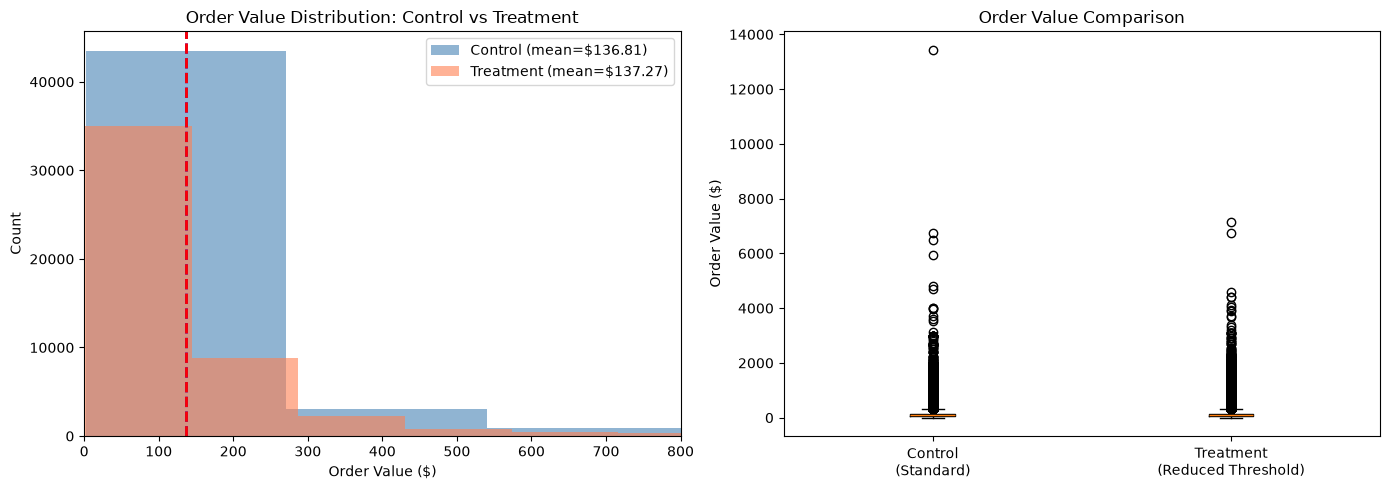

✅ Chart saved to analysis/ab_test_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(control, bins=50, alpha=0.6, 
             label=f'Control (mean=${control.mean():.2f})', 
             color='steelblue')
axes[0].hist(treatment, bins=50, alpha=0.6, 
             label=f'Treatment (mean=${treatment.mean():.2f})', 
             color='coral')
axes[0].axvline(control.mean(), color='blue', 
                linestyle='--', linewidth=2)
axes[0].axvline(treatment.mean(), color='red', 
                linestyle='--', linewidth=2)
axes[0].set_title('Order Value Distribution: Control vs Treatment')
axes[0].set_xlabel('Order Value ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 800)
axes[0].legend()

# Box plot — fixed parameter name
axes[1].boxplot(
    [control, treatment],
    tick_labels=['Control\n(Standard)', 'Treatment\n(Reduced Threshold)']
)
axes[1].set_title('Order Value Comparison')
axes[1].set_ylabel('Order Value ($)')

plt.tight_layout()
plt.savefig('../analysis/ab_test_results.png', dpi=150)
plt.show()
print("✅ Chart saved to analysis/ab_test_results.png")

In [10]:
print("=== A/B TEST COMPLETE SUMMARY ===\n")
print(f"Experiment: Free shipping threshold reduction")
print(f"Control: Standard threshold | n={len(control):,}")
print(f"Treatment: Reduced threshold | n={len(treatment):,}")
print(f"\nControl avg order value: ${control.mean():.2f}")
print(f"Treatment avg order value: ${treatment.mean():.2f}")
print(f"Revenue lift: {lift:.1f}%")
print(f"P-value: {p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")
print(f"Annual revenue impact: ${annual_impact:,.0f}")
print(f"\nRecommendation:", end=" ")
if p_value < 0.05 and lift > 0:
    print("DEPLOY — treatment shows statistically significant revenue lift")
elif p_value < 0.05 and lift < 0:
    print("DO NOT DEPLOY — treatment shows statistically significant revenue decrease")
else:
    print("INCONCLUSIVE — no statistically significant difference found")

=== A/B TEST COMPLETE SUMMARY ===

Experiment: Free shipping threshold reduction
Control: Standard threshold | n=48,239
Treatment: Reduced threshold | n=48,239

Control avg order value: $136.81
Treatment avg order value: $137.27
Revenue lift: 0.3%
P-value: 0.7300 (Not Significant)
Annual revenue impact: $44,605

Recommendation: INCONCLUSIVE — no statistically significant difference found
